<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/classmade/pandas_lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas: знайомство з аналізом даних

**Лекція • 1.5 години**

---

## Що таке pandas?

**pandas** — це найпопулярніша бібліотека Python для роботи з табличними даними. Якщо ви працювали з Excel або Google Sheets — pandas це те саме, але:
- 🚀 значно швидше на великих даних
- 🔁 усе автоматизується кодом (не треба клікати мишкою)
- 🔗 легко поєднується з графіками, машинним навчанням, базами даних

Головний об'єкт у pandas — це **DataFrame** (таблиця з рядками і стовпцями).

> 💡 **Як працювати з зошитом:** запускайте кожну комірку по черзі (Shift + Enter) і дивіться на результат. Експериментуйте — змінюйте код і дивіться, що зміниться!

---

## 1. Імпорт бібліотеки

За традицією pandas імпортують зі скороченням `pd`. Це загальноприйнято — так пишуть усі.

In [ ]:
import pandas as pd

print("pandas версія:", pd.__version__)

pandas версія: 2.2.2


## 2. Завантаження даних

Сьогодні ми працюємо з даними мережі кав'ярень — це файл `coffee_sales.csv` з замовленнями за 6 місяців.

Щоб прочитати CSV-файл, використовуємо `pd.read_csv()`. Результат — це DataFrame, який ми зазвичай зберігаємо у змінну `df`.

In [ ]:
df = pd.read_csv("coffee_sales.csv")

# .head() показує перші 5 рядків
df.head()

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
0,1255,2024-05-21,Львів,Лате,Напої,70,2,0,140.0,Олена
1,1299,2024-05-25,Харків,Чай,Напої,40,2,5,76.0,Богдан
2,1003,2024-01-14,Харків,Маффін,Випічка,60,1,0,60.0,Олена
3,1226,2024-04-21,Львів,Капучіно,Напої,65,1,0,65.0,Олена
4,1114,2024-02-16,Львів,Лате,Напої,70,1,10,63.0,Андрій


### Перший погляд на дані

Кілька найкорисніших команд для знайомства з новим датасетом:

In [ ]:
# Розмір таблиці: (рядки, стовпці)
df.shape

(360, 10)

In [ ]:
# Назви всіх стовпців
df.columns

Index(['order_id', 'date', 'city', 'product', 'category', 'unit_price',
       'quantity', 'discount_pct', 'revenue', 'manager'],
      dtype='object')

In [ ]:
# Загальна інформація: типи даних, кількість непорожніх значень
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      360 non-null    int64  
 1   date          360 non-null    object 
 2   city          360 non-null    object 
 3   product       360 non-null    object 
 4   category      360 non-null    object 
 5   unit_price    360 non-null    int64  
 6   quantity      360 non-null    int64  
 7   discount_pct  360 non-null    int64  
 8   revenue       360 non-null    float64
 9   manager       360 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 28.3+ KB


In [ ]:
# Статистика по числових стовпцях: середнє, мін, макс, тощо
df.describe()

,order_id,unit_price,quantity,discount_pct,revenue
count,360.000000,360.000000,360.000000,360.000000,360.000000
mean,1180.500000,73.972222,2.136111,1.472222,157.688889
std,104.067286,25.290497,1.192281,3.794778,109.374416
min,1001.000000,40.000000,1.000000,0.000000,38.000000
25%,1090.750000,55.000000,1.000000,0.000000,70.000000
50%,1180.500000,65.000000,2.000000,0.000000,120.000000
75%,1270.250000,95.000000,3.000000,0.000000,220.000000
max,1360.000000,120.000000,5.000000,15.000000,600.000000


> 💡 `.head(n)` показує перші `n` рядків, `.tail(n)` — останні. Це найперше, що варто робити з будь-яким новим датасетом.

In [ ]:
# Останні 3 рядки
df.tail(3)

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
357,1032,2024-01-10,Львів,Сендвіч,Їжа,95,4,0,380.0,Олена
358,1296,2024-05-04,Київ,Еспресо,Напої,45,4,0,180.0,Олена
359,1196,2024-04-05,Одеса,Чай,Напої,40,1,5,38.0,Марія


## 3. Вибір стовпців

Щоб вибрати один стовпець, використовуємо квадратні дужки з назвою стовпця.

In [ ]:
# Один стовпець (повертає Series - одновимірну колонку)
df["city"]

,city
0,Львів
1,Харків
2,Харків
3,Львів
4,Львів
...,...
355,Харків
356,Київ
357,Львів
358,Київ


In [ ]:
# Кілька стовпців (повертає DataFrame - подвійні дужки!)
df[["product", "revenue"]].head()

,product,revenue
0,Лате,140.0
1,Чай,76.0
2,Маффін,60.0
3,Капучіно,65.0
4,Лате,63.0


### Базові операції зі стовпцем

Зі стовпцем-числом можна одразу рахувати агрегати:

In [ ]:
print("Загальна виручка:", df["revenue"].sum())
print("Середня виручка:", df["revenue"].mean())
print("Максимальна виручка:", df["revenue"].max())
print("Мінімальна виручка:", df["revenue"].min())
print("Кількість замовлень:", df["revenue"].count())

Загальна виручка: 56768.0
Середня виручка: 157.6888888888889
Максимальна виручка: 600.0
Мінімальна виручка: 38.0
Кількість замовлень: 360


In [ ]:
# Скільки унікальних міст?
df["city"].unique()

array(['Львів', 'Харків', 'Київ', 'Одеса'], dtype=object)

In [ ]:
# Скільки замовлень у кожному місті? value_counts() - дуже корисна команда!
df["city"].value_counts()

,count
city,
Київ,100
Львів,88
Одеса,88
Харків,84


## 4. Фільтрація рядків

Це одна з найважливіших операцій. Ми хочемо вибрати тільки ті рядки, які відповідають умові.

Принцип: всередині `df[...]` ми пишемо умову, яка повертає `True`/`False` для кожного рядка.

In [ ]:
# Тільки замовлення з Києва
kyiv_orders = df[df["city"] == "Київ"]
kyiv_orders.head()

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
5,1164,2024-03-20,Київ,Чізкейк,Десерти,110,2,0,220.0,Марія
6,1338,2024-06-02,Київ,Тірамісу,Десерти,120,3,0,360.0,Андрій
8,1169,2024-03-18,Київ,Маффін,Випічка,60,1,0,60.0,Андрій
9,1193,2024-04-27,Київ,Лате,Напої,70,5,0,350.0,Олена
11,1170,2024-03-10,Київ,Еспресо,Напої,45,1,0,45.0,Марія


In [ ]:
# Скільки замовлень з Києва?
len(kyiv_orders)

100

In [ ]:
# Замовлення з виручкою більше 200 грн
big_orders = df[df["revenue"] > 200]
print("Великих замовлень:", len(big_orders))
big_orders.head()

Великих замовлень: 100


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
5,1164,2024-03-20,Київ,Чізкейк,Десерти,110,2,0,220.0,Марія
6,1338,2024-06-02,Київ,Тірамісу,Десерти,120,3,0,360.0,Андрій
9,1193,2024-04-27,Київ,Лате,Напої,70,5,0,350.0,Олена
13,1213,2024-04-20,Львів,Капучіно,Напої,65,4,0,260.0,Андрій
16,1059,2024-01-22,Київ,Маффін,Випічка,60,4,0,240.0,Андрій


### Кілька умов одночасно

Для поєднання умов використовуємо `&` (І) та `|` (АБО). **Важливо:** кожну умову беремо в дужки!

In [ ]:
# Замовлення з Києва І виручкою більше 150
result = df[(df["city"] == "Київ") & (df["revenue"] > 150)]
result.head()

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
5,1164,2024-03-20,Київ,Чізкейк,Десерти,110,2,0,220.0,Марія
6,1338,2024-06-02,Київ,Тірамісу,Десерти,120,3,0,360.0,Андрій
9,1193,2024-04-27,Київ,Лате,Напої,70,5,0,350.0,Олена
16,1059,2024-01-22,Київ,Маффін,Випічка,60,4,0,240.0,Андрій
19,1192,2024-04-26,Київ,Сендвіч,Їжа,95,4,0,380.0,Андрій


In [ ]:
# Замовлення з категорії Десерти АБО Випічка
sweets = df[(df["category"] == "Десерти") | (df["category"] == "Випічка")]
print("Солодких замовлень:", len(sweets))
sweets.head()

Солодких замовлень: 146


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
2,1003,2024-01-14,Харків,Маффін,Випічка,60,1,0,60.0,Олена
5,1164,2024-03-20,Київ,Чізкейк,Десерти,110,2,0,220.0,Марія
6,1338,2024-06-02,Київ,Тірамісу,Десерти,120,3,0,360.0,Андрій
7,1044,2024-01-01,Харків,Чізкейк,Десерти,110,1,0,110.0,Олена
8,1169,2024-03-18,Київ,Маффін,Випічка,60,1,0,60.0,Андрій


> 💡 Поширена помилка: писати `and`/`or` замість `&`/`|`. У pandas для фільтрації використовуються саме символи `&` та `|`, і кожна умова має бути в дужках.

## 5. Створення нових стовпців

Дуже часто треба порахувати щось нове на основі наявних даних. Новий стовпець створюється просто — присвоюємо значення новій назві.

In [ ]:
# Порахуємо виручку без знижки (повна ціна)
df["full_price"] = df["unit_price"] * df["quantity"]
df[["product", "unit_price", "quantity", "full_price", "revenue"]].head()

,product,unit_price,quantity,full_price,revenue
0,Лате,70,2,140,140.0
1,Чай,40,2,80,76.0
2,Маффін,60,1,60,60.0
3,Капучіно,65,1,65,65.0
4,Лате,70,1,70,63.0


In [ ]:
# Скільки грн втрачено на знижці?
df["discount_amount"] = df["full_price"] - df["revenue"]
df[["product", "full_price", "discount_pct", "discount_amount"]].head()

,product,full_price,discount_pct,discount_amount
0,Лате,140,0,0.0
1,Чай,80,5,4.0
2,Маффін,60,0,0.0
3,Капучіно,65,0,0.0
4,Лате,70,10,7.0


> 💡 Операції застосовуються одразу до ВСЬОГО стовпця — не треба писати цикл! Це називається «векторизація» і це одна з головних переваг pandas.

## 6. Сортування

`sort_values()` сортує таблицю за вказаним стовпцем.

In [ ]:
# Топ-5 найбільших замовлень за виручкою
df.sort_values("revenue", ascending=False).head()

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount
239,1029,2024-01-16,Київ,Тірамісу,Десерти,120,5,0,600.0,Марія,600,0.0
78,1135,2024-03-27,Львів,Тірамісу,Десерти,120,5,0,600.0,Андрій,600,0.0
23,1248,2024-05-24,Львів,Чізкейк,Десерти,110,5,0,550.0,Олена,550,0.0
344,1115,2024-02-05,Харків,Чізкейк,Десерти,110,5,0,550.0,Андрій,550,0.0
302,1076,2024-02-01,Харків,Чізкейк,Десерти,110,5,5,522.5,Олена,550,27.5


In [ ]:
# Найдешевші замовлення (за зростанням)
df.sort_values("revenue", ascending=True).head()

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount
359,1196,2024-04-05,Одеса,Чай,Напої,40,1,5,38.0,Марія,40,2.0
300,1237,2024-04-09,Харків,Чай,Напої,40,1,5,38.0,Андрій,40,2.0
30,1243,2024-05-27,Одеса,Чай,Напої,40,1,0,40.0,Богдан,40,0.0
28,1017,2024-01-25,Львів,Чай,Напої,40,1,0,40.0,Марія,40,0.0
339,1160,2024-03-09,Одеса,Чай,Напої,40,1,0,40.0,Андрій,40,0.0


## 7. Групування — `groupby()` 🔥

Це найпотужніший інструмент pandas і серце аналітики даних. Ідея: розбити дані на групи і порахувати щось для кожної групи.

**Аналогія:** це те саме, що Pivot Table в Excel.

Схема: `df.groupby("стовпець")["що_рахувати"].агрегат()`

In [ ]:
# Загальна виручка по кожному місту
df.groupby("city")["revenue"].sum()

,revenue
city,
Київ,15465.0
Львів,14726.0
Одеса,12988.5
Харків,13588.5


In [ ]:
# Середня виручка по категоріях
df.groupby("category")["revenue"].mean()

,revenue
category,
Їжа,198.550000
Випічка,117.700658
Десерти,253.064286
Напої,129.379888


In [ ]:
# Кількість замовлень по менеджерах
df.groupby("manager")["order_id"].count()

,order_id
manager,
Андрій,118
Богдан,78
Марія,77
Олена,87


### Сортуємо результат групування

Результат groupby — це теж дані, які можна сортувати. Часто хочемо побачити лідерів.

In [ ]:
# Топ продуктів за загальною виручкою
df.groupby("product")["revenue"].sum().sort_values(ascending=False)

,revenue
product,
Чізкейк,9740.50
Тірамісу,7974.00
Сендвіч,6949.25
Раф,6719.25
Лате,5747.00
Маффін,4845.00
Капучіно,4751.50
Круасан,4100.25
Чай,3176.00


In [ ]:
df.index


RangeIndex(start=0, stop=360, step=1)

### Кілька агрегатів одночасно

Метод `.agg()` дозволяє порахувати кілька показників за один раз.

In [ ]:
# По містах: сума, середнє та кількість замовлень
df.groupby("city")["revenue"].agg(["sum", "mean", "count"])

,sum,mean,count
city,,,
Київ,15465.0,154.650000,100
Львів,14726.0,167.340909,88
Одеса,12988.5,147.596591,88
Харків,13588.5,161.767857,84


In [ ]:
# Групування за ДВОМА стовпцями: місто + категорія
df.groupby(["city", "category"])["revenue"].sum()

city    category
Київ    Їжа         1980.75
        Випічка     3020.00
        Десерти     5279.50
        Напої       5184.75
Львів   Їжа         1767.00
        Випічка     2131.00
        Десерти     4692.00
        Напої       6136.00
Одеса   Їжа         1216.00
        Випічка     2312.50
        Десерти     3857.00
        Напої       5603.00
Харків  Їжа         1985.50
        Випічка     1481.75
        Десерти     3886.00
        Напої       6235.25
Name: revenue, dtype: float64

## 8. Робота з датами

Зараз стовпець `date` — це просто текст. Щоб працювати з ним як з датою (виділяти місяць, рік), треба перетворити його через `pd.to_datetime()`.

In [ ]:
# Перетворюємо текст на дату
df["date"] = pd.to_datetime(df["date"])
df["date"].head()

,date
0,2024-05-21
1,2024-05-25
2,2024-01-14
3,2024-04-21
4,2024-02-16


In [ ]:
# Тепер можна виділити місяць, рік, день тижня
df["month"] = df["date"].dt.month
df["day_name"] = df["date"].dt.day_name()
df[["date", "month", "day_name"]].head()

,date,month,day_name
0,2024-05-21,5,Tuesday
1,2024-05-25,5,Saturday
2,2024-01-14,1,Sunday
3,2024-04-21,4,Sunday
4,2024-02-16,2,Friday


In [ ]:
# Виручка по місяцях - класичний часовий аналіз
df.groupby("month")["revenue"].sum()

,revenue
month,
1,9624.25
2,9632.25
3,8540.25
4,9571.00
5,9808.50
6,9591.75


## 9. Збираємо все разом: міні-аналіз

Тепер застосуємо все вивчене, щоб відповісти на реальні бізнес-питання про кав'ярні.

**Питання 1:** Яке місто приносить найбільше грошей?

In [ ]:
revenue_by_city = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
print(revenue_by_city)
print()
print("Лідер:", revenue_by_city.index[0])

city
Київ      15465.0
Львів     14726.0
Харків    13588.5
Одеса     12988.5
Name: revenue, dtype: float64

Лідер: Київ


**Питання 2:** Які 3 продукти найприбутковіші?

In [ ]:
top_products = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
top_products.head(3)

,revenue
product,
Чізкейк,9740.50
Тірамісу,7974.00
Сендвіч,6949.25


**Питання 3:** Хто з менеджерів продав найбільше?

In [ ]:
df.groupby("manager")["revenue"].sum().sort_values(ascending=False).head(1)

,revenue
manager,
Андрій,19540.5


**Питання 4:** Як змінювалась виручка від місяця до місяця?

month
1    9624.25
2    9632.25
3    8540.25
4    9571.00
5    9808.50
6    9591.75
Name: revenue, dtype: float64


<Axes: title={'center': 'Виручка по місяцях'}, xlabel='month'>

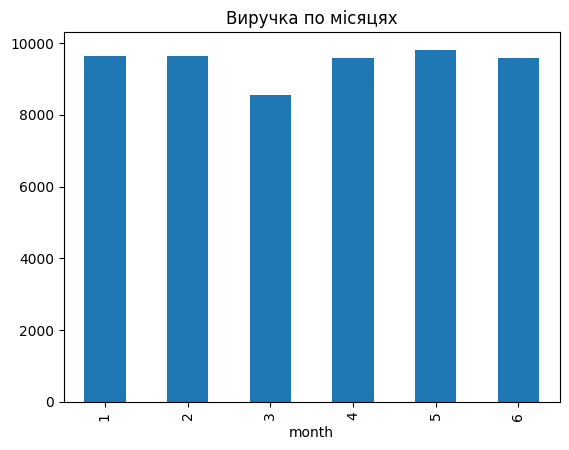

In [ ]:
monthly = df.groupby("month")["revenue"].sum()
print(monthly)

# Можна навіть швидко побудувати графік прямо в pandas!
monthly.plot(kind="bar", title="Виручка по місяцях")

> 💡 pandas вміє будувати швидкі графіки через `.plot()`. Для серйозної візуалізації використовують matplotlib чи seaborn, але для швидкого погляду `.plot()` ідеальний.

---

# 🎯 Завдання для практики

Тепер ваша черга! Спробуйте розв'язати ці завдання самостійно. Дані вже завантажені у `df`.

Якщо щось не виходить — поверніться до прикладів вище, вони містять усе необхідне.

### Завдання 1 ⭐
Виведіть перші 10 рядків таблиці.

In [56]:
# Ваш код:
df.head(10)

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount,month,day_name
0,1255,2024-05-21,Львів,Лате,Напої,70,2,0,140.0,Олена,140,0.0,5,Tuesday
1,1299,2024-05-25,Харків,Чай,Напої,40,2,5,76.0,Богдан,80,4.0,5,Saturday
2,1003,2024-01-14,Харків,Маффін,Випічка,60,1,0,60.0,Олена,60,0.0,1,Sunday
3,1226,2024-04-21,Львів,Капучіно,Напої,65,1,0,65.0,Олена,65,0.0,4,Sunday
4,1114,2024-02-16,Львів,Лате,Напої,70,1,10,63.0,Андрій,70,7.0,2,Friday
5,1164,2024-03-20,Київ,Чізкейк,Десерти,110,2,0,220.0,Марія,220,0.0,3,Wednesday
6,1338,2024-06-02,Київ,Тірамісу,Десерти,120,3,0,360.0,Андрій,360,0.0,6,Sunday
7,1044,2024-01-01,Харків,Чізкейк,Десерти,110,1,0,110.0,Олена,110,0.0,1,Monday
8,1169,2024-03-18,Київ,Маффін,Випічка,60,1,0,60.0,Андрій,60,0.0,3,Monday
9,1193,2024-04-27,Київ,Лате,Напої,70,5,0,350.0,Олена,350,0.0,4,Saturday


### Завдання 2 ⭐
Знайдіть, скільки всього унікальних продуктів у даних.

Підказка: метод `.nunique()` рахує кількість унікальних значень.

In [64]:
# Ваш код:
df['product'].nunique()

10

### Завдання 3 ⭐
Виведіть усі замовлення з міста Львів.

In [65]:
# Ваш код:
df[df['city'] == 'Львів']

,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount,month,day_name
0,1255,2024-05-21,Львів,Лате,Напої,70,2,0,140.0,Олена,140,0.0,5,Tuesday
3,1226,2024-04-21,Львів,Капучіно,Напої,65,1,0,65.0,Олена,65,0.0,4,Sunday
4,1114,2024-02-16,Львів,Лате,Напої,70,1,10,63.0,Андрій,70,7.0,2,Friday
13,1213,2024-04-20,Львів,Капучіно,Напої,65,4,0,260.0,Андрій,260,0.0,4,Saturday
14,1262,2024-05-24,Львів,Маффін,Випічка,60,2,10,108.0,Марія,120,12.0,5,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332,1134,2024-03-17,Львів,Капучіно,Напої,65,3,0,195.0,Олена,195,0.0,3,Sunday
335,1010,2024-01-11,Львів,Лате,Напої,70,2,0,140.0,Богдан,140,0.0,1,Thursday
338,1129,2024-03-15,Львів,Чай,Напої,40,1,0,40.0,Марія,40,0.0,3,Friday
345,1046,2024-01-08,Львів,Капучіно,Напої,65,1,0,65.0,Марія,65,0.0,1,Monday


### Завдання 4 ⭐⭐
Знайдіть усі замовлення, де була застосована знижка (discount_pct більше 0).
Скільки таких замовлень?

In [66]:
# Ваш код:
df[df["discount_pct"] > 0].shape[0]

56

### Завдання 5 ⭐⭐
Створіть новий стовпець `is_big`, який дорівнює `True`, якщо виручка більша за 150, і `False` інакше.

Підказка: `df["is_big"] = df["revenue"] > 150`

In [ ]:
# Ваш код:


### Завдання 6 ⭐⭐
Порахуйте загальну виручку по кожній категорії товарів (Напої, Випічка, Десерти, Їжа).
Відсортуйте за спаданням.

In [ ]:
# Ваш код:


### Завдання 7 ⭐⭐
Яка середня кількість товарів (quantity) у одному замовленні в кожному місті?

In [ ]:
# Ваш код:


### Завдання 8 ⭐⭐⭐
Знайдіть найприбутковіший продукт у КОЖНОМУ місті.

Підказка: згрупуйте за двома стовпцями `["city", "product"]`, порахуйте суму виручки, а потім подумайте, як знайти максимум у кожному місті (можна подивитись на `.idxmax()` або відсортувати).

In [ ]:
# Ваш код:


### Завдання 9 ⭐⭐⭐
Порахуйте, який відсоток від загальної виручки компанії припадає на кожне місто.

Підказка: спочатку порахуйте виручку по містах, потім поділіть на загальну суму і помножте на 100.

In [ ]:
# Ваш код:


### Завдання 10 ⭐⭐⭐
У який день тижня кав'ярні заробляють найбільше?

Підказка: вам знадобиться стовпець `day_name`, який ми створили раніше. Згрупуйте за ним.

In [ ]:
# Ваш код:


---

# 🎉 Чудово!

Сьогодні ви познайомились з основами pandas:

- ✅ Завантаження даних з CSV (`read_csv`)
- ✅ Перший погляд на дані (`head`, `info`, `describe`, `shape`)
- ✅ Вибір стовпців
- ✅ Фільтрація рядків за умовами
- ✅ Створення нових стовпців
- ✅ Сортування (`sort_values`)
- ✅ Групування (`groupby`) — найважливіше!
- ✅ Робота з датами
- ✅ Швидкі графіки (`.plot()`)

### Що далі?
- Метод `merge()` — об'єднання кількох таблиць (як JOIN у SQL)
- Pivot-таблиці (`pivot_table`)
- Обробка пропущених значень (`fillna`, `dropna`)
- Серйозна візуалізація з matplotlib та seaborn

**pandas — це фундамент аналітики даних у Python. Практикуйтесь! 🐼**
